[![Roboflow Notebooks](https://media.roboflow.com/notebooks/template/bannertest2-2.png?ik-sdk-version=javascript-1.4.3&updatedAt=1672932710194)](https://github.com/roboflow/notebooks)

# How to Train RF-DETR Object Detection on a Custom Dataset

---

[![hf space](https://img.shields.io/badge/%F0%9F%A4%97%20Hugging%20Face-Spaces-blue)](https://huggingface.co/spaces/SkalskiP/RF-DETR)
[![colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/roboflow-ai/notebooks/blob/main/notebooks/how-to-finetune-rf-detr-on-detection-dataset.ipynb)
[![roboflow](https://raw.githubusercontent.com/roboflow-ai/notebooks/main/assets/badges/roboflow-blogpost.svg)](https://blog.roboflow.com/rf-detr)
[![code](https://badges.aleen42.com/src/github.svg)](https://github.com/roboflow/rf-detr)

RF-DETR is a real-time transformer architecture for object detection and instance segmentation developed by Roboflow. Built on a DINOv2 vision transformer backbone, RF-DETR delivers state-of-the-art accuracy and latency trade-offs on [Microsoft COCO](https://cocodataset.org/#home) and [RF100-VL](https://github.com/roboflow/rf100-vl).

RF-DETR uses a DINOv2 vision transformer backbone and supports both detection and instance segmentation in a single, consistent API. All core models and code are released under the Apache 2.0 license.

<img alt="rf_detr_1-4_latency_accuracy_object_detection" src="https://storage.googleapis.com/com-roboflow-marketing/rf-detr/rf_detr_1-4_latency_accuracy_object_detection.png" />

## Environment setup

In [1]:
!pip install faster-coco-eval
!pip install torchmetrics

### Configure API Key

To fine-tune RF-DETR, you need to provide your Roboflow API key. Follow these steps:

- Go to your [`Roboflow Settings`](https://app.roboflow.com/settings/api) page. Click `Copy` to copy your private API key.
- In Colab, go to the left pane and click on `Secrets` (🔑).
    - Store your Roboflow API Key under the name `ROBOFLOW_API_KEY`.

In [2]:
import os
from google.colab import userdata

os.environ["ROBOFLOW_API_KEY"] = userdata.get("ROBOFLOW_API_KEY")

### Check GPU availability

Let's make sure that we have access to GPU. We can use `nvidia-smi` command to do that. In case of any problems navigate to `Edit` -> `Notebook settings` -> `Hardware accelerator`, set it to `T4 GPU`, and then click `Save`.

In [3]:
!nvidia-smi

Wed May 20 18:14:35 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   39C    P8              8W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

### Install dependencies

Installs RF-DETR version 1.4.0 or higher, along with Supervision for benchmarking and Roboflow for pulling datasets and uploading models to the Roboflow platform.

In [4]:
!pip install -q rfdetr>=1.4.0 supervision roboflow

### Download example data

Downloads example images for testing. You can use these or replace them with your own images.

In [5]:
!wget -q https://media.roboflow.com/notebooks/examples/dog-2.jpeg
!wget -q https://media.roboflow.com/notebooks/examples/dog-3.jpeg

## Inference with Pre-trained COCO Model

Runs inference on an example image using a pretrained RF-DETR Medium model (trained on COCO). To use a different model size, simply replace `RFDETRMedium` with `RFDETRNano`, `RFDETRSmall`, `RFDETRBase` or `RFDETRLarge` as needed.

[2026-05-20 18:15:03] [INFO] rf-detr - File rf-detr-medium.pth already exists with correct MD5 hash.


[2026-05-20 18:15:03] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-05-20 18:15:03] [WARNING] rf-detr - Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.


[2026-05-20 18:15:05] [INFO] rf-detr - File rf-detr-medium.pth already exists with correct MD5 hash.


[transformers] `loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.
[transformers] `use_return_dict` is deprecated! Use `return_dict` instead!


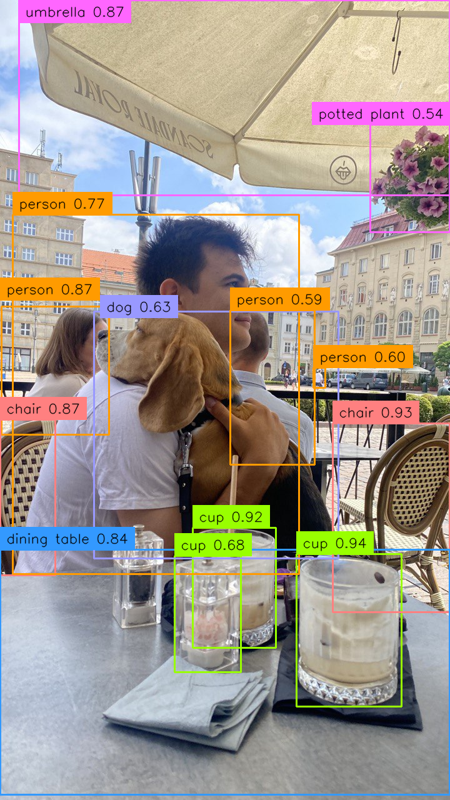

In [6]:
import numpy as np
import supervision as sv

from PIL import Image

from rfdetr import RFDETRMedium
from rfdetr.util.coco_classes import COCO_CLASSES

image = Image.open("dog-2.jpeg")

model = RFDETRMedium(resolution=640)
model.optimize_for_inference()

detections = model.predict(image, threshold=0.5)

color = sv.ColorPalette.from_hex([
    "#ffff00", "#ff9b00", "#ff8080", "#ff66b2", "#ff66ff", "#b266ff",
    "#9999ff", "#3399ff", "#66ffff", "#33ff99", "#66ff66", "#99ff00"
])
text_scale = sv.calculate_optimal_text_scale(resolution_wh=image.size)
thickness = sv.calculate_optimal_line_thickness(resolution_wh=image.size)

bbox_annotator = sv.BoxAnnotator(color=color, thickness=thickness)
label_annotator = sv.LabelAnnotator(
    color=color,
    text_color=sv.Color.BLACK,
    text_scale=text_scale,
    smart_position=True
)

labels = [
    f"{COCO_CLASSES[class_id]} {confidence:.2f}"
    for class_id, confidence
    in zip(detections.class_id, detections.confidence)
]

annotated_image = image.copy()
annotated_image = bbox_annotator.annotate(annotated_image, detections)
annotated_image = label_annotator.annotate(annotated_image, detections, labels)
annotated_image.thumbnail((800, 800))
annotated_image

## Download Dataset from Roboflow Universe

RF-DETR expects the dataset to be in COCO format. Divide your dataset into three subdirectories: `train`, `valid`, and `test`. Each subdirectory should contain its own `_annotations.coco.json` file that holds the annotations for that particular split, along with the corresponding image files. Below is an example of the directory structure:

```
dataset/
├── train/
│   ├── _annotations.coco.json
│   ├── image1.jpg
│   ├── image2.jpg
│   └── ... (other image files)
├── valid/
│   ├── _annotations.coco.json
│   ├── image1.jpg
│   ├── image2.jpg
│   └── ... (other image files)
└── test/
    ├── _annotations.coco.json
    ├── image1.jpg
    ├── image2.jpg
    └── ... (other image files)
```

[Roboflow](https://roboflow.com/annotate) allows you to create object detection datasets from scratch or convert existing datasets from formats like YOLO, and then export them in COCO JSON format for training. You can also explore [Roboflow Universe](https://universe.roboflow.com/) to find pre-labeled datasets for a range of use cases.

In [7]:
from roboflow import download_dataset

dataset = download_dataset("https://universe.roboflow.com/roboflow-jvuqo/basketball-player-detection-2/13", "coco")

loading Roboflow workspace...
loading Roboflow project...


## Train RF-DETR on custom dataset

### Choose the right `batch_size`

Different GPUs have different amounts of VRAM (video memory), which limits how much data they can handle at once during training. To make training work well on any machine, you can adjust two settings: `batch_size` and `grad_accum_steps`. These control how many samples are processed at a time. The key is to keep their product equal to 16 — that’s our recommended total batch size. For example, on powerful GPUs like the A100, set `batch_size=16` and `grad_accum_steps=1`. On smaller GPUs like the T4, use `batch_size=4` and `grad_accum_steps=4`. We use a method called gradient accumulation, which lets the model simulate training with a larger batch size by gradually collecting updates before adjusting the weights.

In [8]:
!pip install pytorch-lightning==2.2.1
!pip install torchmetrics
!pip install lightning

In [9]:
from rfdetr import RFDETRNano

model = RFDETRNano()

model.train(dataset_dir=dataset.location, epochs=10, batch_size=8, grad_accum_steps=2)

[2026-05-20 18:15:31] [INFO] rf-detr - File rf-detr-nano.pth already exists with correct MD5 hash.


[2026-05-20 18:15:31] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-05-20 18:15:31] [WARNING] rf-detr - Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.


[2026-05-20 18:15:33] [INFO] rf-detr - File rf-detr-nano.pth already exists with correct MD5 hash.


[2026-05-20 18:15:36] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-05-20 18:15:36] [WARNING] rf-detr - Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.


[2026-05-20 18:15:38] [INFO] rf-detr - File rf-detr-nano.pth already exists with correct MD5 hash.


...

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/callbacks/model_checkpoint.py:653: Checkpoint directory /content/output exists and is not empty.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.utilities.rank_zero:Loading `train_dataloader` to estimate number of stepping batches.
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
INFO:pytorch_lightning.callbacks.model_summary:
  | Name        | Type         | Params
---------------------------------------------
0 | model       | LWDETR       | 30.2 M
1 | criterion   | SetCriterion | 0     
2 | postprocess | PostProcess  | 0     
---------------------------------------------
30.2 M    Trainable params
0         Non-trainable params
30.2 M    Total params
120.660   Total estimated model params size (MB)


Output()

[2026-05-20 18:15:48] [INFO] rf-detr - Best EMA mAP improved to 0.0000 (epoch 0)
[2026-05-20 18:19:00] [INFO] rf-detr - Best regular mAP saved to /content/output/checkpoint_best_regular.pth (epoch 0)
[2026-05-20 18:19:00] [INFO] rf-detr - Best EMA mAP improved to 0.2708 (epoch 0)
[2026-05-20 18:22:15] [INFO] rf-detr - Best regular mAP saved to /content/output/checkpoint_best_regular.pth (epoch 1)
[2026-05-20 18:22:21] [INFO] rf-detr - Best EMA mAP improved to 0.3327 (epoch 1)
[2026-05-20 18:25:38] [INFO] rf-detr - Best regular mAP saved to /content/output/checkpoint_best_regular.pth (epoch 2)
[2026-05-20 18:25:40] [INFO] rf-detr - Best EMA mAP improved to 0.3675 (epoch 2)
[2026-05-20 18:29:02] [INFO] rf-detr - Best EMA mAP improved to 0.3850 (epoch 3)
[2026-05-20 18:32:22] [INFO] rf-detr - Best regular mAP saved to /content/output/checkpoint_best_regular.pth (epoch 4)
[2026-05-20 18:32:28] [INFO] rf-detr - Best EMA mAP improved to 0.3977 (epoch 4)
[2026-05-20 18:35:39] [INFO] rf-detr -

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=10` reached.


[2026-05-20 18:50:31] [INFO] rf-detr - Best total checkpoint saved from EMA (regular=0.4159, ema=0.4346)


In [14]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("/content/output/metrics.csv")
df.head(19)


,epoch,step,train/cardinality_error,train/cardinality_error_0,train/cardinality_error_enc,train/class_error,train/loss,train/loss_bbox,train/loss_bbox_0,train/loss_bbox_enc,...,val/ema_mAP_50,val/ema_mAP_50_95,val/ema_mAR,val/loss,val/mAP_50,val/mAP_50_95,val/mAP_75,val/mAR,val/precision,val/recall
0,0,49,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0,65,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.499238,0.270770,0.393881,4.278588,0.501469,0.271531,0.267323,0.391582,0.650776,0.512920
2,0,65,3881.834229,3881.811523,3747.729248,24.790758,5.030037,0.035966,0.038327,0.042135,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1,99,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1,131,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.645188,0.332654,0.429028,4.062587,0.641061,0.331899,0.299760,0.428703,0.731762,0.640924
5,1,131,3882.141113,3882.130615,3719.144775,5.088205,4.347625,0.027714,0.029204,0.031131,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,2,149,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,2,197,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.686701,0.367463,0.454852,4.001181,0.691055,0.363707,0.335098,0.449207,0.841965,0.670502
8,2,197,3882.048340,3882.153320,3693.127930,3.472874,4.111286,0.025356,0.026822,0.027729,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,3,199,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [15]:
!ls -la /content/output

total 1298508
drwxr-xr-x 2 root root      4096 May 20 18:50 .
drwxr-xr-x 1 root root      4096 May 20 18:14 ..
-rw-r--r-- 1 root root 483505921 May 20 18:49 checkpoint_9.ckpt
-rw-r--r-- 1 root root 120863025 May 20 18:49 checkpoint_best_ema.pth
-rw-r--r-- 1 root root 120864973 May 20 18:49 checkpoint_best_regular.pth
-rw------- 1 root root 120852729 May 20 18:50 checkpoint_best_total.pth
-rw-r--r-- 1 root root        88 May 20 18:07 events.out.tfevents.1779300468.0bbe07ec68c4.14725.0
-rw-r--r-- 1 root root        88 May 20 18:08 events.out.tfevents.1779300534.0bbe07ec68c4.14725.1
-rw-r--r-- 1 root root        88 May 20 18:10 events.out.tfevents.1779300606.0bbe07ec68c4.14725.2
-rw-r--r-- 1 root root     19427 May 20 18:50 events.out.tfevents.1779300943.0bbe07ec68c4.21989.0
-rw-r--r-- 1 root root         3 May 20 18:50 hparams.yaml
-rw-r--r-- 1 root root 483505857 May 20 18:49 last.ckpt
-rw-r--r-- 1 root root      8046 May 20 18:50 metrics.csv


## Evaluate Fine-tuned RF-DETR Model

Before benchmarking the model, we need to load the best saved checkpoint. To ensure it fits on the GPU, we first need to free up GPU memory. This involves deleting any remaining references to previously used objects, triggering Python’s garbage collector, and clearing the CUDA memory cache.

In [16]:
import gc
import torch
import weakref

def cleanup_gpu_memory(obj=None, verbose: bool = False):

    if not torch.cuda.is_available():
        if verbose:
            print("[INFO] CUDA is not available. No GPU cleanup needed.")
        return

    def get_memory_stats():
        allocated = torch.cuda.memory_allocated()
        reserved = torch.cuda.memory_reserved()
        return allocated, reserved

    torch.cuda.synchronize()

    if verbose:
        alloc, reserv = get_memory_stats()
        print(f"[Before] Allocated: {alloc / 1024**2:.2f} MB | Reserved: {reserv / 1024**2:.2f} MB")

    # Ensure we drop all strong references
    if obj is not None:
        ref = weakref.ref(obj)
        del obj
        if ref() is not None and verbose:
            print("[WARNING] Object not fully garbage collected yet.")

    gc.collect()
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()

    torch.cuda.synchronize()

    if verbose:
        alloc, reserv = get_memory_stats()
        print(f"[After]  Allocated: {alloc / 1024**2:.2f} MB | Reserved: {reserv / 1024**2:.2f} MB")

In [17]:
cleanup_gpu_memory(model, verbose=True)

[Before] Allocated: 116.53 MB | Reserved: 166.00 MB
[WARNING] Object not fully garbage collected yet.
[After]  Allocated: 0.00 MB | Reserved: 2.00 MB


We load the best-performing model from the `checkpoint_best_total.pth` file using the `RFDETRMedium` class. This checkpoint contains the trained weights from our most successful training run. After loading, we call `optimize_for_inference()`, which prepares the model for efficient inference.

In [18]:
model = RFDETRNano(pretrain_weights="/content/output/checkpoint_best_total.pth")
model.optimize_for_inference()

[2026-05-20 18:57:00] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-05-20 18:57:00] [WARNING] rf-detr - Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-05-20 18:57:01] [WARNING] rf-detr - Checkpoint has 6 classes but model is configured for 90. Using checkpoint class count (6). Pass num_classes=6 to suppress this warning.
Converting a tensor to a Python boolean might cause the trace to be incorrect. We can't record the data flow of Python values, so this value will be treated as a constant in the future. This means that the trace might not generalize to other inputs!
Converting a tensor to a Python boolean might cause the trace to be incorrect. We can't record the data flow of Python values, so this value will be trea

In [19]:
import supervision as sv

ds = sv.DetectionDataset.from_coco(
    images_directory_path=f"{dataset.location}/test",
    annotations_path=f"{dataset.location}/test/_annotations.coco.json",
)

In [20]:
import supervision as sv
from tqdm import tqdm
from supervision.metrics import MeanAveragePrecision

targets = []
predictions = []

for path, image, annotations in tqdm(ds):
    image = Image.open(path)
    detections = model.predict(image, threshold=0)

    targets.append(annotations)
    predictions.append(detections)

100%|██████████| 169/169 [00:09<00:00, 17.85it/s]


In [21]:
map_metric = MeanAveragePrecision()
map_result = map_metric.update(predictions, targets).compute()
print(map_result)

Average Precision (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.453
Average Precision (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.776
Average Precision (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.443
Average Precision (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.221
Average Precision (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.692
Average Precision (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.827


## Run Inference with Fine-tuned RF-DETR Model

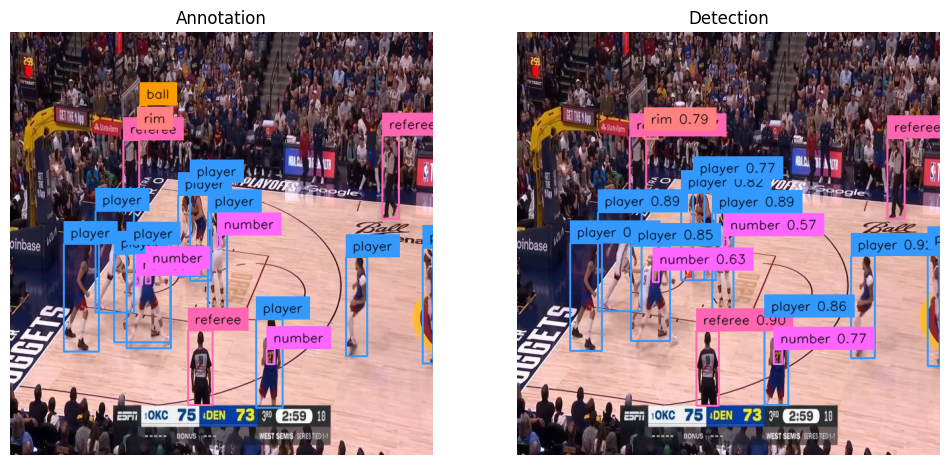

In [22]:
from rfdetr import RFDETRBase
import supervision as sv
from PIL import Image

path, image, annotations = ds[0]
image = Image.open(path)

detections = model.predict(image, threshold=0.5)

text_scale = sv.calculate_optimal_text_scale(resolution_wh=image.size)
thickness = sv.calculate_optimal_line_thickness(resolution_wh=image.size)
color = sv.ColorPalette.from_hex([
    "#ffff00", "#ff9b00", "#ff66ff", "#3399ff", "#ff66b2", "#ff8080",
    "#b266ff", "#9999ff", "#66ffff", "#33ff99", "#66ff66", "#99ff00"
])

bbox_annotator = sv.BoxAnnotator(color=color,thickness=thickness)
label_annotator = sv.LabelAnnotator(
    color=color,
    text_color=sv.Color.BLACK,
    text_scale=text_scale)

annotations_labels = [
    f"{ds.classes[class_id]}"
    for class_id
    in annotations.class_id
]

detections_labels = [
    f"{ds.classes[class_id]} {confidence:.2f}"
    for class_id, confidence
    in zip(detections.class_id, detections.confidence)
]

annotation_image = image.copy()
annotation_image = bbox_annotator.annotate(annotation_image, annotations)
annotation_image = label_annotator.annotate(annotation_image, annotations, annotations_labels)

detections_image = image.copy()
detections_image = bbox_annotator.annotate(detections_image, detections)
detections_image = label_annotator.annotate(detections_image, detections, detections_labels)

sv.plot_images_grid(images=[annotation_image, detections_image], grid_size=(1, 2), titles=["Annotation", "Detection"])